# Protein Backbone Diffusion V3

V3 keeps the V2 DDPM data pipeline, splits, normalization, masking, sampling loop, and structural diagnostics, but replaces the flattened residue-wise 1D denoiser with a pragmatic atom-level graph denoiser.

Each backbone atom is represented as a node with coordinate input, atom-type embedding, residue-position embedding, timestep conditioning, and a residue-derived atom mask. Local message-passing edges follow the backbone topology (`N-CA-C-O`, adjacent `C-N`, and adjacent `CA-CA`) so the model has a stronger inductive bias for local 3D geometry without jumping to a full EGNN.


## 1. Runtime and setup

This section detects the runtime, optionally mounts Google Drive, locates the repository, resolves the CATH data directory, installs small notebook dependencies, and sets the seed/device/output directories. By default V3 writes artifacts to Google Drive when Drive mounts successfully, otherwise it falls back to the repo-local `results/v3/` directory. Google Drive is no longer required for PyCharm or other IDE execution.

Runtime flags for local or IDE execution:

- set `BACKBONE_DIFFUSION_MOUNT_DRIVE=0` to skip Google Drive mounting; this also disables table writes by default
- set `BACKBONE_DIFFUSION_SAVE_TABLES=0` to disable CSV/Parquet table artifact writes explicitly
- set `BACKBONE_DIFFUSION_SAVE_TABLES=1` to write tables even when Drive mounting is skipped
- set `BACKBONE_DIFFUSION_ARTIFACT_BASE_DIR=/path/to/results` to override the artifact root


In [2]:
import base64
import os
import random
import subprocess
import sys
import time
from getpass import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from IPython.display import Markdown, display
from torch.utils.data import DataLoader

try:
    import google.colab  # type: ignore
    from google.colab import drive, userdata  # type: ignore
    IN_COLAB = True
except ImportError:
    drive = None  # type: ignore
    userdata = None  # type: ignore
    IN_COLAB = False


def env_flag(name: str, default: bool) -> bool:
    """Parse a boolean environment flag."""
    value = os.environ.get(name)
    if value is None:
        return default
    return value.strip().lower() in {'1', 'true', 'yes', 'y', 'on'}


DRIVE_MOUNT_MODE = os.environ.get('BACKBONE_DIFFUSION_MOUNT_DRIVE', 'auto').strip().lower()
DRIVE_MOUNT_SKIPPED = DRIVE_MOUNT_MODE in {'0', 'false', 'no', 'off', 'skip'}
SAVE_TABLE_ARTIFACTS = env_flag('BACKBONE_DIFFUSION_SAVE_TABLES', not DRIVE_MOUNT_SKIPPED)

DRIVE_MOUNTPOINT = Path('/content/drive')
DRIVE_MYDRIVE = DRIVE_MOUNTPOINT / 'MyDrive'
DRIVE_MOUNTED = False

if IN_COLAB and drive is not None and not DRIVE_MOUNT_SKIPPED:
    try:
        drive.mount(str(DRIVE_MOUNTPOINT), force_remount=False)
        DRIVE_MOUNTED = DRIVE_MYDRIVE.exists()
    except Exception as exc:  # noqa: BLE001
        if DRIVE_MOUNT_MODE in {'1', 'true', 'yes', 'on', 'required'}:
            raise RuntimeError('Google Drive mounting was explicitly requested but failed.') from exc
        print(f'Google Drive mount skipped after failure: {exc}')
else:
    print('Google Drive mount skipped.')

if DRIVE_MOUNTED:
    print(f'Drive mounted: {DRIVE_MYDRIVE}')
else:
    print('Running without Google Drive mount; artifacts default to the repo-local results directory.')

REPO_REMOTE_URL = os.environ.get('GITHUB_REPO_URL', 'https://github.com/mitsenkov/latent-structure-diffusion.git')
REPO_BRANCH = os.environ.get('GITHUB_REPO_BRANCH', 'main')
REPO_CLONE_DIR = Path(os.environ.get('REPO_CLONE_DIR', '/content/latent-structure-diffusion'))
REPO_DRIVE_DIR = Path(os.environ.get('REPO_DRIVE_DIR', '/content/drive/MyDrive/latent-structure-diffusion'))
DEFAULT_CATH_FOLDER_ID = os.environ.get('CATH_SHARED_FOLDER_ID', '')
LOCAL_DATA_CACHE = Path(os.environ.get('CATH_LOCAL_CACHE', '/content/cath_backbone_data'))
ALLOW_GIT_CLONE = os.environ.get('ALLOW_GIT_CLONE', '1' if IN_COLAB else '0') == '1'


def get_github_token() -> str | None:
    """Return a GitHub token from env, Colab userdata, or an interactive prompt."""
    token = os.environ.get('GITHUB_TOKEN')
    if token:
        return token.strip()
    if IN_COLAB:
        try:
            token = userdata.get('GITHUB_TOKEN')
        except Exception:  # noqa: BLE001
            token = None
        if token:
            return str(token).strip()
    if ALLOW_GIT_CLONE:
        token = getpass('Paste the GitHub token with read access to this repo: ').strip()
        if token:
            return token
    return None


def find_repo_root(start_paths: list[Path] | None = None) -> Path | None:
    """Return the repository root if a checkout is already present."""
    candidates = start_paths or [Path.cwd().resolve(), REPO_CLONE_DIR, REPO_DRIVE_DIR]
    for start in candidates:
        if not start.exists():
            continue
        for candidate in [start, *start.parents]:
            if (candidate / 'pyproject.toml').exists() and (candidate / 'src').exists():
                return candidate
    return None


def build_auth_header(token: str) -> str:
    """Build a Git basic auth header for private GitHub clone access."""
    raw = f'x-access-token:{token}'.encode('utf-8')
    encoded = base64.b64encode(raw).decode('ascii')
    return f'AUTHORIZATION: basic {encoded}'


def bootstrap_repo() -> Path:
    """Make the repo available in Colab or reuse an existing checkout."""
    existing_root = find_repo_root()
    if existing_root is not None:
      if IN_COLAB:
          token = get_github_token()
          if token:
              pull_cmd = [
                  'git',
                  '-C',
                  str(existing_root),
                  '-c',
                  f'http.extraheader={build_auth_header(token)}',
                  'pull',
                  '--ff-only',
              ]
              subprocess.run(pull_cmd, check=True, capture_output=True, text=True)
      return existing_root

    if not IN_COLAB:
        raise FileNotFoundError(
            'Could not locate the repository root. Expected a folder containing pyproject.toml and src/.'
        )

    if not ALLOW_GIT_CLONE:
        raise FileNotFoundError(
            'Could not locate a local repo checkout. In Colab, set ALLOW_GIT_CLONE=1 or define GITHUB_TOKEN.'
        )

    token = get_github_token()
    if not token:
        raise FileNotFoundError(
            'GitHub cloning was enabled, but no token was provided.'
        )

    REPO_CLONE_DIR.parent.mkdir(parents=True, exist_ok=True)
    clone_cmd = [
        'git',
        '-c',
        f'http.extraheader={build_auth_header(token)}',
        'clone',
        '--branch',
        REPO_BRANCH,
        REPO_REMOTE_URL,
        str(REPO_CLONE_DIR),
    ]
    try:
        subprocess.run(clone_cmd, check=True, capture_output=True, text=True)
    except subprocess.CalledProcessError as exc:
        stderr = (exc.stderr or '').strip()
        stdout = (exc.stdout or '').strip()
        details = '\n'.join(part for part in [stdout, stderr] if part)
        raise RuntimeError(
            'GitHub clone failed in this Colab runtime. The token may be missing, invalid, or lack repo read access. '            f'Command: git clone --branch {REPO_BRANCH} {REPO_REMOTE_URL} {REPO_CLONE_DIR}\n{details}'
        ) from exc
    return REPO_CLONE_DIR


def ensure_gdown_installed() -> None:
    """Install gdown on demand."""
    try:
        import gdown  # type: ignore  # noqa: F401
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gdown'])


def resolve_data_dir() -> Path:
    """Resolve the dataset directory without requiring a Drive mount."""
    env_dir = os.environ.get('CATH_DATA_DIR')
    if env_dir:
        candidate = Path(env_dir)
        if (candidate / 'chain_set.jsonl').exists() and (candidate / 'chain_set_splits.json').exists():
            return candidate

    local_candidate = LOCAL_DATA_CACHE
    if (local_candidate / 'chain_set.jsonl').exists() and (local_candidate / 'chain_set_splits.json').exists():
        return local_candidate

    if IN_COLAB and DEFAULT_CATH_FOLDER_ID:
        ensure_gdown_installed()
        import gdown  # type: ignore

        local_candidate.mkdir(parents=True, exist_ok=True)
        url = f'https://drive.google.com/drive/folders/{DEFAULT_CATH_FOLDER_ID}'
        gdown.download_folder(url=url, output=str(local_candidate), quiet=False, use_cookies=False)
        if (local_candidate / 'chain_set.jsonl').exists() and (local_candidate / 'chain_set_splits.json').exists():
            return local_candidate

    raise FileNotFoundError(
        'Could not resolve the CATH dataset directory. Set CATH_DATA_DIR to a local path with chain_set.jsonl '
        'and chain_set_splits.json, or allow the notebook to download the public shared folder.'
    )


REPO_ROOT = bootstrap_repo()
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = resolve_data_dir()

DEFAULT_ARTIFACT_DIR = (
    DRIVE_MYDRIVE / 'latent-structure-generation' / 'results'
    if DRIVE_MOUNTED
    else REPO_ROOT / 'results'
)
ARTIFACT_BASE_DIR = Path(os.environ.get('BACKBONE_DIFFUSION_ARTIFACT_BASE_DIR', str(DEFAULT_ARTIFACT_DIR)))
ARTIFACT_RUN_NAME = os.environ.get('BACKBONE_DIFFUSION_RUN_NAME', 'v3')
ARTIFACT_DIR = ARTIFACT_BASE_DIR / ARTIFACT_RUN_NAME
FIGURE_DIR = ARTIFACT_DIR / 'figures'
TABLE_DIR = ARTIFACT_DIR / 'tables'
CHECKPOINT_DIR = ARTIFACT_DIR / 'checkpoints'
for directory in [FIGURE_DIR, TABLE_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

def save_table_artifact(frame: pd.DataFrame, name: str, *, drop_columns: list[str] | None = None) -> dict[str, Path]:
    """Save a dataframe as CSV and Parquet under the run's tables directory."""
    if not SAVE_TABLE_ARTIFACTS:
        return {}
    export_frame = frame.drop(columns=[column for column in (drop_columns or []) if column in frame.columns]).copy()
    csv_path = TABLE_DIR / f'{name}.csv'
    parquet_path = TABLE_DIR / f'{name}.parquet'
    export_frame.to_csv(csv_path, index=False)
    try:
        export_frame.to_parquet(parquet_path, index=False)
    except Exception as exc:  # noqa: BLE001
        print(f'Could not write Parquet for {name}: {exc}')
    return {'csv': csv_path, 'parquet': parquet_path}

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    device_name = torch.cuda.get_device_name(0)
else:
    device_name = 'CPU'

try:
    import py3Dmol  # type: ignore
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'py3Dmol'])
    import py3Dmol  # type: ignore

if SAVE_TABLE_ARTIFACTS:
    try:
        import pyarrow  # type: ignore  # noqa: F401
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyarrow'])

from latent_structure_generation.backbone_diffusion import (
    BACKBONE_ATOMS,
    BackboneDataset,
    BackboneNormalizationStats,
    apply_coordinate_normalisation,
    backbone_coords_to_protein,
    backbone_structure_summary,
    build_normalization_stats_from_dataframe,
    build_overlapping_backbone_chunks,
    collate_backbone_examples,
    centre_coordinates,
    create_noise_schedule,
    extract_backbone_from_coords_dict,
    flatten_backbone,
    invert_coordinate_normalisation,
    masked_coordinate_rmse,
    masked_noise_mse,
    pad_or_crop_backbone,
    predict_x0,
    q_sample,
    sample_backbone,
    sample_timesteps,
    sinusoidal_timestep_embedding,
    structure_validity_report,
    to_pdb,
    unflatten_backbone,
)
from latent_structure_generation.plots import plot_ca_trace

print(f'Repository root: {REPO_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Artifacts: {ARTIFACT_DIR}')
print(f'Google Drive mounted: {DRIVE_MOUNTED}')
print(f'Table artifact saving enabled: {SAVE_TABLE_ARTIFACTS}')
print(f'Seed: {SEED}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Selected device: {device}')
print(f'Device name: {device_name}')
print(f'GitHub clone enabled: {ALLOW_GIT_CLONE}')
print(f'GitHub token present: {bool(os.environ.get("GITHUB_TOKEN") or (IN_COLAB and "GITHUB_TOKEN" in getattr(userdata, "keys", lambda: [])()))}')


Google Drive mount skipped after failure: mount failed
Running without Google Drive mount; artifacts default to the repo-local results directory.


Retrieving folder contents


Processing file <REDACTED> chain_set_splits.json
Processing file <REDACTED> chain_set.jsonl


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=<REDACTED>
To: /content/cath_backbone_data/chain_set_splits.json
100%|██████████| 784k/784k [00:00<00:00, 167MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=<REDACTED>
From (redirected): https://drive.google.com/uc?id=<REDACTED>
To: /content/cath_backbone_data/chain_set.jsonl
100%|██████████| 517M/517M [00:01<00:00, 325MB/s] 
Download completed


Repository root: /content/latent-structure-diffusion
Data directory: /content/cath_backbone_data
Artifacts: /content/latent-structure-diffusion/results/v3
Google Drive mounted: False
Table artifact saving enabled: True
Seed: 42
CUDA available: True
Selected device: cuda
Device name: NVIDIA L4
GitHub clone enabled: True
GitHub token present: False


## 2. Load the starter CATH tables

This reuses the provided Google Drive layout from the starter notebook. The split names are canonicalized to `train`, `validation`, and `test` so later code does not depend on `val` vs `validation` naming drift.

In [3]:
chain_set_path = DATA_DIR / 'chain_set.jsonl'
split_path = DATA_DIR / 'chain_set_splits.json'

print(f'Reading {chain_set_path}')
df = pd.read_json(chain_set_path, lines=True)
print(f'Reading {split_path}')
chain_splits = pd.read_json(split_path, lines=True)


def canonical_split_name(name: str) -> str:
    """Map split labels to the canonical notebook names."""
    return {'val': 'validation', 'validation': 'validation', 'train': 'train', 'test': 'test'}.get(name, name)


split_lookup: dict[str, str] = {}

# Preserve the true train/validation/test buckets first.
for column in ['train', 'validation', 'test']:
    if column not in chain_splits.columns:
        continue
    canonical = canonical_split_name(column)
    values = chain_splits[column].iloc[0]
    for record_name in values:
        split_lookup.setdefault(record_name, canonical)

# cath_nodes is auxiliary metadata; use it only for records not already assigned.
if 'cath_nodes' in chain_splits.columns:
    cath_nodes = chain_splits['cath_nodes'].iloc[0]
    for record_name in cath_nodes.keys():
        split_lookup.setdefault(record_name, 'cath_nodes')

df['split'] = df['name'].map(split_lookup).fillna('unknown')
df['split'] = df['split'].map(canonical_split_name)

available_splits = sorted(df['split'].dropna().unique().tolist())
print('Available splits:', available_splits)
print('Split counts:')
print(df['split'].value_counts(dropna=False).sort_index())
print('Columns:', list(df.columns))
print('Example row keys:', list(df.iloc[0].index))

save_table_artifact(df, 'raw_chain_manifest', drop_columns=['coords'])

Reading /content/cath_backbone_data/chain_set.jsonl
Reading /content/cath_backbone_data/chain_set_splits.json
Available splits: ['cath_nodes', 'test', 'train', 'unknown', 'validation']
Split counts:
split
cath_nodes     1820
test           1120
train         18024
unknown          96
validation      608
Name: count, dtype: int64
Columns: ['seq', 'coords', 'num_chains', 'name', 'CATH', 'split']
Example row keys: ['seq', 'coords', 'num_chains', 'name', 'CATH', 'split']


{'csv': PosixPath('/content/latent-structure-diffusion/results/v3/tables/raw_chain_manifest.csv'),
 'parquet': PosixPath('/content/latent-structure-diffusion/results/v3/tables/raw_chain_manifest.parquet')}

## 3. Data audit before training

This is the required review phase. It checks shapes, masks, invalid values, real lengths, truncation, coordinate ranges, backbone bond lengths, and a few visual examples before any training code runs.

In [4]:
from collections import defaultdict


def move_batch_to_device(batch: dict[str, object], target_device: torch.device) -> dict[str, object]:
    """Move tensor values in a batch to the selected device."""
    moved: dict[str, object] = {}
    for key, value in batch.items():
        moved[key] = value.to(target_device) if torch.is_tensor(value) else value
    return moved


def audit_dataframe(split_df: pd.DataFrame, split_name: str, max_length: int) -> pd.DataFrame:
    """Audit one split and return a per-example summary table."""
    rows: list[dict[str, object]] = []
    for _, row in split_df.reset_index(drop=True).iterrows():
        record_id = row['name']
        try:
            coords, residue_mask = extract_backbone_from_coords_dict(row['coords'])
            raw_length = int(coords.shape[0])
            real_length = int(residue_mask.sum())
            coords_fixed, mask_fixed, truncated = pad_or_crop_backbone(coords, residue_mask, max_length)
            coords_t = torch.tensor(coords_fixed, dtype=torch.float32)
            mask_t = torch.tensor(mask_fixed.astype(np.float32), dtype=torch.float32)
            has_nan = bool(np.isnan(coords_fixed).any())
            has_inf = bool(np.isinf(coords_fixed).any())
            zero_real_residues = int(((np.abs(coords_fixed).sum(axis=(1, 2)) == 0.0) & mask_fixed).sum())
            summary = backbone_structure_summary(coords_t, mask_t)
            rows.append(
                {
                    'record_id': record_id,
                    'split': split_name,
                    'raw_length': raw_length,
                    'real_length': real_length,
                    'padded_length': int(mask_fixed.shape[0]),
                    'truncated': bool(truncated),
                    'has_nan': has_nan,
                    'has_inf': has_inf,
                    'zero_real_residues': zero_real_residues,
                    'keep_example': bool(real_length > 0 and not has_nan and not has_inf),
                    **summary,
                }
            )
        except Exception as exc:  # noqa: BLE001
            rows.append(
                {
                    'record_id': record_id,
                    'split': split_name,
                    'raw_length': np.nan,
                    'real_length': 0,
                    'padded_length': max_length,
                    'truncated': False,
                    'has_nan': True,
                    'has_inf': True,
                    'zero_real_residues': 0,
                    'keep_example': False,
                    'audit_error': str(exc),
                    'n_residues': 0,
                    'mean_adjacent_ca': np.nan,
                    'fraction_adjacent_ca_in_band': np.nan,
                    'mean_n_ca': np.nan,
                    'mean_ca_c': np.nan,
                    'mean_c_o': np.nan,
                    'mean_c_n': np.nan,
                    'radius_of_gyration': np.nan,
                }
            )
    return pd.DataFrame(rows)


def summarize_lengths(audit_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize real lengths, padding, and truncation for one split."""
    if audit_df.empty:
        return pd.DataFrame([
            {
                'split': 'unknown',
                'n_examples': 0,
                'min_real_length': np.nan,
                'median_real_length': np.nan,
                'max_real_length': np.nan,
                'mean_real_length': np.nan,
                'mean_padding_fraction': np.nan,
                'truncated_fraction': np.nan,
            }
        ])

    if 'keep_example' not in audit_df.columns:
        valid = audit_df.copy()
    else:
        valid = audit_df[audit_df['keep_example'].fillna(False)].copy()
    if valid.empty:
        split_name = audit_df['split'].iloc[0] if 'split' in audit_df.columns and len(audit_df) else 'unknown'
        return pd.DataFrame([
            {
                'split': split_name,
                'n_examples': 0,
                'min_real_length': np.nan,
                'median_real_length': np.nan,
                'max_real_length': np.nan,
                'mean_real_length': np.nan,
                'mean_padding_fraction': np.nan,
                'truncated_fraction': np.nan,
            }
        ])

    lengths = valid['real_length'].astype(int)
    padded_fraction = 1.0 - (lengths / valid['padded_length'].astype(int))
    return pd.DataFrame(
        [
            {
                'split': valid['split'].iloc[0],
                'n_examples': int(len(valid)),
                'min_real_length': int(lengths.min()),
                'median_real_length': float(lengths.median()),
                'max_real_length': int(lengths.max()),
                'mean_real_length': float(lengths.mean()),
                'mean_padding_fraction': float(padded_fraction.mean()),
                'truncated_fraction': float(valid['truncated'].mean()),
            }
        ]
    )


def coordinate_moments(split_df: pd.DataFrame, max_length: int) -> dict[str, np.ndarray | float]:
    """Compute mean/std/RMS statistics over real atom coordinates only."""
    sum_xyz = np.zeros(3, dtype=np.float64)
    sum_sq_xyz = np.zeros(3, dtype=np.float64)
    count = 0
    rg_values: list[float] = []
    for _, row in split_df.reset_index(drop=True).iterrows():
        coords, residue_mask = extract_backbone_from_coords_dict(row['coords'])
        if residue_mask.sum() == 0:
            continue
        coords_fixed, mask_fixed, _ = pad_or_crop_backbone(coords, residue_mask, max_length)
        coords_t = torch.tensor(coords_fixed, dtype=torch.float32)
        mask_t = torch.tensor(mask_fixed.astype(np.float32), dtype=torch.float32)
        centred = centre_coordinates(coords_t.unsqueeze(0), mask_t.unsqueeze(0))[0]
        real = centred[mask_t.bool()].reshape(-1, 3)
        sum_xyz += real.sum(dim=0).cpu().numpy()
        sum_sq_xyz += (real.pow(2)).sum(dim=0).cpu().numpy()
        count += int(real.shape[0])
        rg_values.append(float(backbone_structure_summary(coords_t, mask_t)['radius_of_gyration']))
    mean = sum_xyz / max(count, 1)
    var = sum_sq_xyz / max(count, 1) - mean**2
    std = np.sqrt(np.clip(var, 1e-6, None))
    return {'mean': mean, 'std': std, 'rms': float(np.sqrt(np.mean(sum_sq_xyz / max(count, 1)))), 'count': count, 'radius_of_gyration_mean': float(np.mean(rg_values)) if rg_values else float('nan')}


MAX_SEQ_LENGTH = 256
train_audit = audit_dataframe(df[df['split'] == 'train'], 'train', MAX_SEQ_LENGTH)
val_audit = audit_dataframe(df[df['split'] == 'validation'], 'validation', MAX_SEQ_LENGTH)
test_audit = audit_dataframe(df[df['split'] == 'test'], 'test', MAX_SEQ_LENGTH)

audit_df = pd.concat([train_audit, val_audit, test_audit], ignore_index=True)

length_summary_df = pd.concat(
    [summarize_lengths(train_audit), summarize_lengths(val_audit), summarize_lengths(test_audit)],
    ignore_index=True,
)

print('Audit summary by split:')
display(length_summary_df)

print('Invalid / filtered examples by split:')
filter_summary = (
    audit_df.groupby('split', as_index=False)
    .agg(total_examples=('record_id', 'count'), kept_examples=('keep_example', 'sum'), invalid_examples=('keep_example', lambda s: int((~s).sum())), truncated_examples=('truncated', 'sum'))
)
filter_summary['filtered_out'] = filter_summary['total_examples'] - filter_summary['kept_examples']
display(filter_summary)

print('Coordinate and structure summary on the training split:')
train_moments = coordinate_moments(df[df['split'] == 'train'], MAX_SEQ_LENGTH)
print(train_moments)

print('Head of the audit table:')
display(audit_df.head(8))

save_table_artifact(train_audit, 'train_audit')
save_table_artifact(val_audit, 'validation_audit')
save_table_artifact(test_audit, 'test_audit')
save_table_artifact(audit_df, 'audit_table')
save_table_artifact(length_summary_df, 'length_summary')
save_table_artifact(filter_summary, 'filter_summary')

print('Shape checks:')
print('coords expected shape: (B, L, 4, 3)')
print('mask expected shape: (B, L)')
print('backbone atom axis:', BACKBONE_ATOMS)
print('training split examples kept:', int(train_audit['keep_example'].sum()))
print('validation split examples kept:', int(val_audit['keep_example'].sum()))
print('test split examples kept:', int(test_audit['keep_example'].sum()))

Audit summary by split:


,split,n_examples,min_real_length,median_real_length,max_real_length,mean_real_length,mean_padding_fraction,truncated_fraction
0,train,18024,39,204.0,500,218.666611,0.145834,0.411895
1,validation,608,40,146.0,475,174.185855,0.319587,0.217105
2,test,1120,40,138.0,497,162.196429,0.366420,0.167857


Invalid / filtered examples by split:


,split,total_examples,kept_examples,invalid_examples,truncated_examples,filtered_out
0,test,1120,1120,0,188,0
1,train,18024,18024,0,7424,0
2,validation,608,608,0,132,0


Coordinate and structure summary on the training split:
{'mean': array([4.35094914e-08, 9.17244435e-10, 1.15692106e-08]), 'std': array([10.8189943 , 10.77414569, 11.26774933]), 'rms': 10.95589685875415, 'count': 13140264, 'radius_of_gyration_mean': 17.75437718812381}
Head of the audit table:


,record_id,split,raw_length,real_length,padded_length,truncated,has_nan,has_inf,zero_real_residues,keep_example,n_residues,mean_adjacent_ca,fraction_adjacent_ca_in_band,mean_n_ca,mean_ca_c,mean_c_o,mean_c_n,radius_of_gyration
0,12as.A,train,330,327,256,True,False,False,0,True,253.0,3.801517,1.000000,1.458675,1.524882,1.231658,1.330370,18.822926
1,132l.A,train,129,129,256,False,False,False,0,True,129.0,3.790657,1.000000,1.451698,1.522182,1.229839,1.329097,13.762529
2,153l.A,train,185,185,256,False,False,False,0,True,185.0,3.793203,1.000000,1.452797,1.520918,1.227060,1.328758,14.764102
3,16pk.A,train,415,415,256,True,False,False,0,True,256.0,3.802165,0.996078,1.458607,1.525249,1.233422,1.329715,21.210670
4,16vp.A,train,366,311,256,True,False,False,0,True,256.0,3.808722,1.000000,1.458273,1.526411,1.231872,1.330091,22.820541
5,19hc.A,train,292,292,256,True,False,False,0,True,256.0,3.799515,1.000000,1.462690,1.524048,1.233184,1.330454,22.213974
6,1a00.B,train,146,146,256,False,False,False,0,True,146.0,3.808571,1.000000,1.469882,1.522288,1.242783,1.322277,14.951940
7,1a02.F,train,56,53,256,False,False,False,0,True,53.0,3.803103,1.000000,1.457479,1.523339,1.226574,1.327927,22.990189


Shape checks:
coords expected shape: (B, L, 4, 3)
mask expected shape: (B, L)
backbone atom axis: ('N', 'CA', 'C', 'O')
training split examples kept: 18024
validation split examples kept: 608
test split examples kept: 1120


### What the audit established

The audit keeps padded positions, drops only examples with no valid backbone residues, and reports the amount of truncation caused by fixed-length batching. The same summary tables also give the train-only statistics needed for normalization. Long training chains are then expanded into overlapping fixed-length chunks so we stop throwing away so much of each protein.

In [5]:
# Build chain-level filtered split tables first.
train_chain_df = df[df['split'] == 'train'].reset_index(drop=True)
validation_chain_df = df[df['split'] == 'validation'].reset_index(drop=True)
test_chain_df = df[df['split'] == 'test'].reset_index(drop=True)

train_df = train_chain_df[train_audit['keep_example'].values].reset_index(drop=True)
validation_df = validation_chain_df[val_audit['keep_example'].values].reset_index(drop=True)
test_df = test_chain_df[test_audit['keep_example'].values].reset_index(drop=True)

# Expand long training chains into overlapping 256-residue windows.
TRAIN_CHUNK_STRIDE = 128
train_chunked_df = build_overlapping_backbone_chunks(
    train_df,
    split='train',
    max_length=MAX_SEQ_LENGTH,
    stride=TRAIN_CHUNK_STRIDE,
    record_id_column='name',
)

print('Filtered split sizes:')
print('train:', len(train_df))
print('validation:', len(validation_df))
print('test:', len(test_df))
print('train chunks:', len(train_chunked_df))
print('unique train parent chains:', train_chunked_df['parent_chain_id'].nunique())
print('training chunk stride:', TRAIN_CHUNK_STRIDE)
chunk_count_summary = train_chunked_df.groupby('parent_chain_id').size()
print('chunk count per parent chain: min', int(chunk_count_summary.min()), 'median', float(chunk_count_summary.median()), 'max', int(chunk_count_summary.max()))
print('chunk length range:', int(train_chunked_df['chunk_length'].min()), 'to', int(train_chunked_df['chunk_length'].max()))
chunk_count_summary_df = chunk_count_summary.rename_axis('parent_chain_id').reset_index(name='chunk_count')

save_table_artifact(train_df, 'train_chains_manifest', drop_columns=['coords'])
save_table_artifact(validation_df, 'validation_chains_manifest', drop_columns=['coords'])
save_table_artifact(test_df, 'test_chains_manifest', drop_columns=['coords'])
save_table_artifact(train_chunked_df, 'train_chunked_manifest', drop_columns=['coords'])
save_table_artifact(chunk_count_summary_df, 'train_chunk_counts')

train_dataset = BackboneDataset(train_chunked_df, split='train', max_length=MAX_SEQ_LENGTH, record_id_column='chunk_id')
validation_dataset = BackboneDataset(validation_df, split='validation', max_length=MAX_SEQ_LENGTH)
test_dataset = BackboneDataset(test_df, split='test', max_length=MAX_SEQ_LENGTH)

BATCH_SIZE = 32
NUM_WORKERS = 2 if IN_COLAB else 0
PIN_MEMORY = device.type == 'cuda'

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_backbone_examples,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_backbone_examples,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_backbone_examples,
)

example_batch = next(iter(train_loader))
print('Example batch keys:', list(example_batch.keys()))
print('coords shape:', tuple(example_batch['coords'].shape), 'dtype:', example_batch['coords'].dtype, 'device:', example_batch['coords'].device)
print('mask shape:', tuple(example_batch['mask'].shape), 'dtype:', example_batch['mask'].dtype, 'device:', example_batch['mask'].device)
print('lengths shape:', tuple(example_batch['length'].shape))
print('real_length shape:', tuple(example_batch['real_length'].shape))
print('truncated shape:', tuple(example_batch['truncated'].shape))
print('first record ids:', example_batch['record_id'][:3])
print('first parent chain ids:', example_batch['parent_chain_id'][:3])
print('first chunk ids:', example_batch['chunk_id'][:3])

Filtered split sizes:
train: 18024
validation: 608
test: 1120
train chunks: 27706
unique train parent chains: 18024
training chunk stride: 128
chunk count per parent chain: min 1 median 1.0 max 3
chunk length range: 40 to 256
Example batch keys: ['record_id', 'split', 'coords', 'mask', 'length', 'real_length', 'truncated', 'parent_chain_id', 'chunk_id', 'chunk_index', 'chunk_start', 'chunk_end', 'chunk_length', 'chunk_count', 'source_length']
coords shape: (32, 256, 4, 3) dtype: torch.float32 device: cpu
mask shape: (32, 256) dtype: torch.float32 device: cpu
lengths shape: (32,)
real_length shape: (32,)
truncated shape: (32,)
first record ids: ['3m1r.A__chunk001_0066_0322', '2lcc.A__chunk000_0000_0076', '1iio.A__chunk000_0000_0084']
first parent chain ids: ['3m1r.A', '2lcc.A', '1iio.A']
first chunk ids: ['3m1r.A__chunk001_0066_0322', '2lcc.A__chunk000_0000_0076', '1iio.A__chunk000_0000_0084']


## 4. Visual sanity checks on real data

This shows a few training examples before any normalization or diffusion is applied. The point is to confirm that the backbone traces and masks line up with the expected protein geometry.

Real example 0: 3m1r.A__chunk001_0066_0322
{'n_residues': 256.0, 'mean_adjacent_ca': 4.3893208503723145, 'fraction_adjacent_ca_in_band': 0.9803921580314636, 'mean_n_ca': 1.4416983127593994, 'mean_ca_c': 1.5079243183135986, 'mean_c_o': 1.2156610488891602, 'mean_c_n': 1.9492661952972412, 'radius_of_gyration': 18.1343994140625}


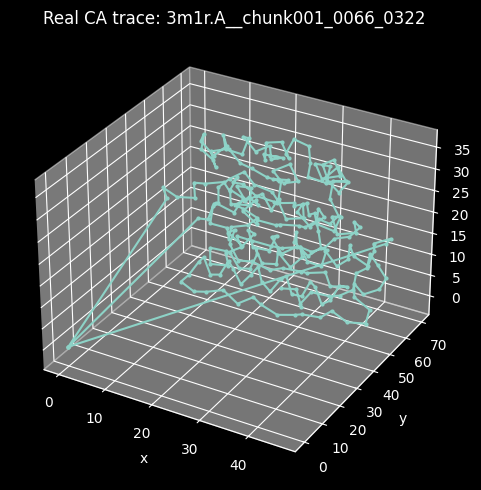

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Real example 1: 2lcc.A__chunk000_0000_0076
{'n_residues': 76.0, 'mean_adjacent_ca': 3.7634761333465576, 'fraction_adjacent_ca_in_band': 1.0, 'mean_n_ca': 1.4420362710952759, 'mean_ca_c': 1.5160902738571167, 'mean_c_o': 1.234939694404602, 'mean_c_n': 1.3061072826385498, 'radius_of_gyration': 13.3764066696167}


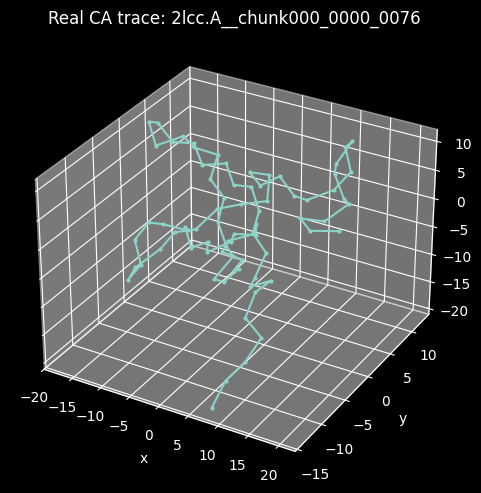

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [6]:
def plot_ca_trace_from_batch(coords: torch.Tensor, mask: torch.Tensor, title: str):
    """Plot a CA trace using the existing plotting helper."""
    ca = coords[mask.bool(), 1, :].detach().cpu().numpy()
    fig, ax = plot_ca_trace(ca, title=title)
    plt.show()
    return fig, ax


def render_backbone_example(coords: torch.Tensor, mask: torch.Tensor, title: str):
    """Render one backbone structure as a PDB-backed py3Dmol viewer."""
    protein = backbone_coords_to_protein(coords, mask)
    pdb_str = to_pdb(protein)
    view = py3Dmol.view(width=700, height=500)
    view.addModel(pdb_str, 'pdb')
    view.setStyle({'cartoon': {'color': 'spectrum'}})
    view.zoomTo()
    view.show()
    return view


for index in range(min(2, example_batch['coords'].shape[0])):
    real_coords = example_batch['coords'][index]
    real_mask = example_batch['mask'][index]
    print(f'Real example {index}:', example_batch['record_id'][index])
    print(backbone_structure_summary(real_coords, real_mask))
    plot_ca_trace_from_batch(real_coords, real_mask.bool(), title=f"Real CA trace: {example_batch['record_id'][index]}")
    render_backbone_example(real_coords, real_mask, title=f"Real backbone: {example_batch['record_id'][index]}")

## 5. Preprocessing and train-only normalization

The model sees centered backbone coordinates that are standardized with statistics computed from the training split only. This cell also checks the flatten / unflatten / inverse-transform path before training starts.

In [7]:
normalization_stats = build_normalization_stats_from_dataframe(train_df)
print('Normalization mean:', normalization_stats.mean)
print('Normalization std:', normalization_stats.std)

smoke_batch = next(iter(train_loader))
coords = smoke_batch['coords']
mask = smoke_batch['mask']
coords_centered = centre_coordinates(coords, mask)
coords_norm = apply_coordinate_normalisation(coords_centered, mask, normalization_stats)
coords_flat = flatten_backbone(coords_norm)
coords_roundtrip = unflatten_backbone(coords_flat)
coords_denorm = invert_coordinate_normalisation(coords_roundtrip, normalization_stats)

print('coords_centered:', tuple(coords_centered.shape))
print('coords_norm:', tuple(coords_norm.shape))
print('coords_flat:', tuple(coords_flat.shape))
print('coords_roundtrip:', tuple(coords_roundtrip.shape))
print('coords_denorm:', tuple(coords_denorm.shape))
print('max inverse diff:', float((coords_denorm - coords_centered).abs().max().item()))
print('smoke-test mask sum:', float(mask.sum().item()))

Normalization mean: tensor([3.9541e-09, 6.3693e-09, 1.4911e-08])
Normalization std: tensor([11.5103, 11.4502, 12.1258])
coords_centered: (32, 256, 4, 3)
coords_norm: (32, 256, 4, 3)
coords_flat: (32, 256, 12)
coords_roundtrip: (32, 256, 4, 3)
coords_denorm: (32, 256, 4, 3)
max inverse diff: 1.9073486328125e-06
smoke-test mask sum: 7389.0


## 6. Diffusion utilities and atom-level graph denoiser


In [8]:
TIMESTEPS = 100
noise_schedule = create_noise_schedule(TIMESTEPS, device=device)


class BackboneAtomGraphBlock(nn.Module):
    """Local atom-graph message passing block for normalized backbone coordinates."""

    def __init__(self, hidden_dim: int, edge_type_count: int):
        super().__init__()
        self.edge_embedding = nn.Embedding(edge_type_count, hidden_dim // 4)
        edge_dim = hidden_dim // 4
        self.message_mlp = nn.Sequential(
            nn.LayerNorm(hidden_dim * 2 + edge_dim + 4),
            nn.Linear(hidden_dim * 2 + edge_dim + 4, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.update_mlp = nn.Sequential(
            nn.LayerNorm(hidden_dim * 2),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.ffn = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.SiLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
        )

    def forward(
        self,
        h: torch.Tensor,
        coords: torch.Tensor,
        node_mask: torch.Tensor,
        edge_src: torch.Tensor,
        edge_dst: torch.Tensor,
        edge_type: torch.Tensor,
    ) -> torch.Tensor:
        src_h = h[:, edge_src]
        dst_h = h[:, edge_dst]
        rel = coords[:, edge_src] - coords[:, edge_dst]
        dist2 = rel.pow(2).sum(dim=-1, keepdim=True)
        edge_emb = self.edge_embedding(edge_type).unsqueeze(0).expand(h.shape[0], -1, -1)
        edge_mask = (node_mask[:, edge_src] * node_mask[:, edge_dst]).unsqueeze(-1)

        messages = self.message_mlp(torch.cat([src_h, dst_h, rel, dist2, edge_emb], dim=-1)) * edge_mask
        aggregated = torch.zeros_like(h)
        aggregated.index_add_(1, edge_dst, messages)

        degree = torch.zeros(h.shape[0], h.shape[1], 1, device=h.device, dtype=h.dtype)
        degree.index_add_(1, edge_dst, edge_mask)
        aggregated = aggregated / degree.clamp_min(1.0)

        h = h + self.update_mlp(torch.cat([h, aggregated], dim=-1))
        h = h + self.ffn(h)
        return h * node_mask.unsqueeze(-1)


class BackboneAtomGraphDenoiser(nn.Module):
    """Atom-level point-cloud denoiser with fixed local backbone graph edges.

    The public interface intentionally matches the V1/V2 denoiser: input and output
    are flattened `(B, L, 12)` tensors, so the DDPM training, sampling, and metric
    code can stay unchanged. Internally each residue contributes four atom nodes.
    """

    def __init__(
        self,
        max_length: int = 256,
        hidden_dim: int = 192,
        num_layers: int = 4,
        time_embedding_dim: int = 128,
    ):
        super().__init__()
        self.max_length = max_length
        self.hidden_dim = hidden_dim
        self.time_embedding_dim = time_embedding_dim
        self.atom_count = len(BACKBONE_ATOMS)
        self.edge_type_count = 5

        self.coord_proj = nn.Linear(3, hidden_dim)
        self.mask_proj = nn.Linear(1, hidden_dim)
        self.atom_emb = nn.Embedding(self.atom_count, hidden_dim)
        self.residue_emb = nn.Embedding(max_length, hidden_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embedding_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.blocks = nn.ModuleList(
            [BackboneAtomGraphBlock(hidden_dim, self.edge_type_count) for _ in range(num_layers)]
        )
        self.output_proj = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 3),
        )

        edge_src, edge_dst, edge_type = self._build_backbone_edges(max_length)
        self.register_buffer('edge_src', edge_src, persistent=False)
        self.register_buffer('edge_dst', edge_dst, persistent=False)
        self.register_buffer('edge_type', edge_type, persistent=False)

    def _atom_node(self, residue_index: int, atom_index: int) -> int:
        return residue_index * self.atom_count + atom_index

    def _add_bidirectional_edge(
        self,
        sources: list[int],
        destinations: list[int],
        edge_types: list[int],
        left: int,
        right: int,
        edge_type: int,
    ) -> None:
        sources.extend([left, right])
        destinations.extend([right, left])
        edge_types.extend([edge_type, edge_type])

    def _build_backbone_edges(self, max_length: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        sources: list[int] = []
        destinations: list[int] = []
        edge_types: list[int] = []
        for residue_index in range(max_length):
            n = self._atom_node(residue_index, 0)
            ca = self._atom_node(residue_index, 1)
            c = self._atom_node(residue_index, 2)
            o = self._atom_node(residue_index, 3)
            self._add_bidirectional_edge(sources, destinations, edge_types, n, ca, 0)
            self._add_bidirectional_edge(sources, destinations, edge_types, ca, c, 1)
            self._add_bidirectional_edge(sources, destinations, edge_types, c, o, 2)
            if residue_index + 1 < max_length:
                next_n = self._atom_node(residue_index + 1, 0)
                next_ca = self._atom_node(residue_index + 1, 1)
                self._add_bidirectional_edge(sources, destinations, edge_types, c, next_n, 3)
                self._add_bidirectional_edge(sources, destinations, edge_types, ca, next_ca, 4)
        return (
            torch.tensor(sources, dtype=torch.long),
            torch.tensor(destinations, dtype=torch.long),
            torch.tensor(edge_types, dtype=torch.long),
        )

    def forward(self, x_t: torch.Tensor, t: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        if x_t.ndim != 3 or x_t.shape[-1] != 12:
            raise ValueError('x_t must have shape (B, L, 12).')
        if mask.ndim != 2:
            raise ValueError('mask must have shape (B, L).')
        if x_t.shape[:2] != mask.shape:
            raise ValueError('x_t and mask must agree on batch and length dimensions.')
        if x_t.shape[1] > self.max_length:
            raise ValueError(f'Sequence length {x_t.shape[1]} exceeds max_length={self.max_length}.')

        batch_size, seq_len, _ = x_t.shape
        node_count = seq_len * self.atom_count
        coords = x_t.reshape(batch_size, seq_len, self.atom_count, 3).reshape(batch_size, node_count, 3)
        node_mask = mask.unsqueeze(-1).expand(-1, -1, self.atom_count).reshape(batch_size, node_count).float()

        atom_ids = torch.arange(self.atom_count, device=x_t.device).view(1, 1, self.atom_count).expand(batch_size, seq_len, -1).reshape(batch_size, node_count)
        residue_ids = torch.arange(seq_len, device=x_t.device).view(1, seq_len, 1).expand(batch_size, -1, self.atom_count).reshape(batch_size, node_count)
        time_emb = self.time_mlp(sinusoidal_timestep_embedding(t, self.time_embedding_dim)).unsqueeze(1)

        h = (
            self.coord_proj(coords)
            + self.atom_emb(atom_ids)
            + self.residue_emb(residue_ids)
            + self.mask_proj(node_mask.unsqueeze(-1))
            + time_emb
        )
        h = h * node_mask.unsqueeze(-1)

        edge_keep = (self.edge_src < node_count) & (self.edge_dst < node_count)
        edge_src = self.edge_src[edge_keep].to(x_t.device)
        edge_dst = self.edge_dst[edge_keep].to(x_t.device)
        edge_type = self.edge_type[edge_keep].to(x_t.device)
        for block in self.blocks:
            h = block(h, coords, node_mask, edge_src, edge_dst, edge_type)

        pred = self.output_proj(h) * node_mask.unsqueeze(-1)
        return pred.reshape(batch_size, seq_len, self.atom_count, 3).reshape(batch_size, seq_len, 12)


MODEL_TYPE = 'BackboneAtomGraphDenoiser'
MODEL_HIDDEN_DIM = 192
MODEL_NUM_LAYERS = 4
MODEL_TIME_EMBEDDING_DIM = 128
model = BackboneAtomGraphDenoiser(
    max_length=MAX_SEQ_LENGTH,
    hidden_dim=MODEL_HIDDEN_DIM,
    num_layers=MODEL_NUM_LAYERS,
    time_embedding_dim=MODEL_TIME_EMBEDDING_DIM,
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)
print('Model type:', MODEL_TYPE)
print('Model parameters:', sum(parameter.numel() for parameter in model.parameters()))
print('Schedule keys:', list(noise_schedule.keys()))
print('Schedule shapes:')
for key, value in noise_schedule.items():
    print(key, tuple(value.shape), value.device)

with torch.no_grad():
    demo_coords = coords_norm.to(device)
    demo_mask = mask.to(device)
    demo_t = sample_timesteps(demo_coords.shape[0], TIMESTEPS, device)
    demo_noise = torch.randn_like(flatten_backbone(demo_coords))
    demo_x0 = flatten_backbone(demo_coords)
    demo_xt = q_sample(demo_x0, demo_t, demo_noise, noise_schedule['alpha_bars'])
    demo_pred = model(demo_xt, demo_t, demo_mask)

print('x0 shape:', tuple(demo_x0.shape))
print('xt shape:', tuple(demo_xt.shape))
print('pred shape:', tuple(demo_pred.shape))
assert demo_pred.shape == demo_x0.shape


BackboneAtomGraphDenoiser(
  (coord_proj): Linear(in_features=3, out_features=192, bias=True)
  (mask_proj): Linear(in_features=1, out_features=192, bias=True)
  (atom_emb): Embedding(4, 192)
  (residue_emb): Embedding(256, 192)
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=192, bias=True)
    (1): SiLU()
    (2): Linear(in_features=192, out_features=192, bias=True)
  )
  (blocks): ModuleList(
    (0-3): 4 x BackboneAtomGraphBlock(
      (edge_embedding): Embedding(5, 48)
      (message_mlp): Sequential(
        (0): LayerNorm((436,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=436, out_features=192, bias=True)
        (2): SiLU()
        (3): Linear(in_features=192, out_features=192, bias=True)
      )
      (update_mlp): Sequential(
        (0): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=384, out_features=192, bias=True)
        (2): SiLU()
        (3): Linear(in_features=192, out_features=19

## 7. Training, validation, and test evaluation

The loop tracks DDPM noise loss and an auxiliary x0 reconstruction RMSE. Validation and test are strictly masked and use the same train-derived normalization.

In [9]:
def prepare_batch_for_diffusion(batch: dict[str, object], target_device: torch.device, stats: BackboneNormalizationStats) -> tuple[torch.Tensor, torch.Tensor]:
    """Move a batch to device and return normalized flattened coords plus the mask."""
    batch = move_batch_to_device(batch, target_device)
    coords = batch['coords']
    mask = batch['mask']
    coords_centered = centre_coordinates(coords, mask)
    coords_norm = apply_coordinate_normalisation(coords_centered, mask, stats)
    coords_flat = flatten_backbone(coords_norm)
    return coords_flat, mask


def run_epoch(
    model: torch.nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None,
    stats: BackboneNormalizationStats,
    schedule: dict[str, torch.Tensor],
    target_device: torch.device,
) -> dict[str, float]:
    """Run one training or evaluation epoch."""
    is_training = optimizer is not None
    model.train(is_training)
    totals = defaultdict(float)
    n_batches = 0

    for batch in loader:
        coords_flat, mask = prepare_batch_for_diffusion(batch, target_device, stats)
        t = sample_timesteps(coords_flat.shape[0], TIMESTEPS, target_device)
        noise = torch.randn_like(coords_flat)
        x_t = q_sample(coords_flat, t, noise, schedule['alpha_bars'])

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            pred_noise = model(x_t, t, mask)
            loss = masked_noise_mse(pred_noise, noise, mask)
            x0_pred = predict_x0(x_t, t, pred_noise, schedule['alpha_bars'])
            recon_rmse = masked_coordinate_rmse(x0_pred, coords_flat, mask)
            if is_training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        totals['loss'] += float(loss.detach().cpu())
        totals['x0_rmse'] += float(recon_rmse.detach().cpu())
        n_batches += 1

    return {key: value / max(n_batches, 1) for key, value in totals.items()}


EPOCHS = 5
history: list[dict[str, float]] = []
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    train_metrics = run_epoch(model, train_loader, optimizer, normalization_stats, noise_schedule, device)
    val_metrics = run_epoch(model, validation_loader, None, normalization_stats, noise_schedule, device)
    test_metrics = run_epoch(model, test_loader, None, normalization_stats, noise_schedule, device)

    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_x0_rmse': train_metrics['x0_rmse'],
        'validation_loss': val_metrics['loss'],
        'validation_x0_rmse': val_metrics['x0_rmse'],
        'test_loss': test_metrics['loss'],
        'test_x0_rmse': test_metrics['x0_rmse'],
        'lr': optimizer.param_groups[0]['lr'],
        'epoch_seconds': time.time() - start_time,
    }
    history.append(row)
    if row['validation_loss'] < best_val_loss:
        best_val_loss = row['validation_loss']
        torch.save(
            {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'normalization_mean': normalization_stats.mean,
                'normalization_std': normalization_stats.std,
                'timesteps': TIMESTEPS,
                'max_length': MAX_SEQ_LENGTH,
                'batch_size': BATCH_SIZE,
                'seed': SEED,
                'model_type': MODEL_TYPE,
                'model_hidden_dim': MODEL_HIDDEN_DIM,
                'model_num_layers': MODEL_NUM_LAYERS,
                'model_time_embedding_dim': MODEL_TIME_EMBEDDING_DIM,
            },
            CHECKPOINT_DIR / 'best_backbone_diffusion.pt',
        )
    print(
        f"Epoch {epoch:02d} | train loss {row['train_loss']:.5f} | val loss {row['validation_loss']:.5f} | "
        f"test loss {row['test_loss']:.5f} | val x0 RMSE {row['validation_x0_rmse']:.4f} | "
        f"{row['epoch_seconds']:.1f}s"
    )

history_df = pd.DataFrame(history)
display(history_df)
save_table_artifact(history_df, 'backbone_diffusion_history')

Epoch 01 | train loss 0.23077 | val loss 0.15636 | test loss 0.16015 | val x0 RMSE 0.2048 | 124.4s
Epoch 02 | train loss 0.16291 | val loss 0.14703 | test loss 0.15155 | val x0 RMSE 0.1980 | 124.9s
Epoch 03 | train loss 0.15611 | val loss 0.15153 | test loss 0.15532 | val x0 RMSE 0.2056 | 124.9s
Epoch 04 | train loss 0.14979 | val loss 0.13683 | test loss 0.13880 | val x0 RMSE 0.1924 | 124.9s
Epoch 05 | train loss 0.14393 | val loss 0.13854 | test loss 0.13949 | val x0 RMSE 0.1889 | 124.9s


,epoch,train_loss,train_x0_rmse,validation_loss,validation_x0_rmse,test_loss,test_x0_rmse,lr,epoch_seconds
0,1,0.230773,0.247883,0.156362,0.204783,0.160151,0.199556,0.001,124.385910
1,2,0.162914,0.205332,0.147025,0.198010,0.151554,0.197083,0.001,124.867149
2,3,0.156109,0.198996,0.151531,0.205563,0.155322,0.198663,0.001,124.911771
3,4,0.149789,0.197862,0.136832,0.192372,0.138804,0.191634,0.001,124.860359
4,5,0.143932,0.196517,0.138535,0.188948,0.139491,0.191719,0.001,124.923232


{'csv': PosixPath('/content/latent-structure-diffusion/results/v3/tables/backbone_diffusion_history.csv'),
 'parquet': PosixPath('/content/latent-structure-diffusion/results/v3/tables/backbone_diffusion_history.parquet')}

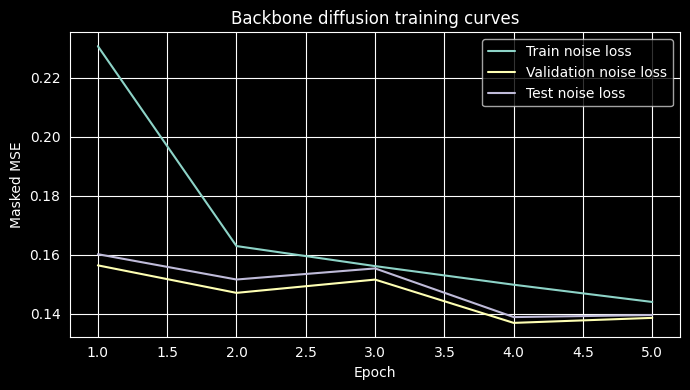

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_df['epoch'], history_df['train_loss'], label='Train noise loss')
ax.plot(history_df['epoch'], history_df['validation_loss'], label='Validation noise loss')
ax.plot(history_df['epoch'], history_df['test_loss'], label='Test noise loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Masked MSE')
ax.set_title('Backbone diffusion training curves')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'backbone_diffusion_losses.png', dpi=150)
plt.show()

## 8. Sampling and evaluation

This samples backbones from Gaussian noise, then denormalizes them back into coordinate space for structural evaluation and visualization.

In [11]:
model.eval()
with torch.no_grad():
    eval_batch = next(iter(validation_loader))
    sample_mask = eval_batch['mask'][:4].to(device)
    sampled_flat = sample_backbone(
        model,
        noise_schedule,
        shape=(sample_mask.shape[0], MAX_SEQ_LENGTH, 12),
        mask=sample_mask,
        device=device,
    )
    sampled_coords_norm = unflatten_backbone(sampled_flat)
    sampled_coords = invert_coordinate_normalisation(sampled_coords_norm, normalization_stats)

    real_coords = eval_batch['coords'][:4]
    real_mask = eval_batch['mask'][:4]

real_rows = []
generated_rows = []
for index in range(sampled_coords.shape[0]):
    real_rows.append({'kind': 'real', 'index': index, **backbone_structure_summary(real_coords[index], real_mask[index])})
    generated_rows.append({'kind': 'generated', 'index': index, **backbone_structure_summary(sampled_coords[index].cpu(), sample_mask[index].cpu())})

real_eval_df = pd.DataFrame(real_rows)
generated_eval_df = pd.DataFrame(generated_rows)

display(real_eval_df)
display(generated_eval_df)

comparison_df = pd.concat([real_eval_df, generated_eval_df], ignore_index=True)
comparison_summary = comparison_df.groupby('kind', as_index=False).mean(numeric_only=True)
display(comparison_summary)
save_table_artifact(real_eval_df, 'real_eval_metrics')
save_table_artifact(generated_eval_df, 'generated_eval_metrics')
save_table_artifact(comparison_df, 'real_vs_generated_summary')
save_table_artifact(comparison_summary, 'real_vs_generated_summary_mean')

,kind,index,n_residues,mean_adjacent_ca,fraction_adjacent_ca_in_band,mean_n_ca,mean_ca_c,mean_c_o,mean_c_n,radius_of_gyration
0,real,0,171.0,3.805476,0.994012,1.460498,1.527345,1.232196,1.327362,16.227869
1,real,1,63.0,3.814094,1.000000,1.460700,1.528333,1.234096,1.333291,16.453768
2,real,2,180.0,3.805939,1.000000,1.458334,1.522972,1.228173,1.329856,16.873392
3,real,3,256.0,3.826390,1.000000,1.457568,1.525439,1.230243,1.332404,18.050728


,kind,index,n_residues,mean_adjacent_ca,fraction_adjacent_ca_in_band,mean_n_ca,mean_ca_c,mean_c_o,mean_c_n,radius_of_gyration
0,generated,0,171.0,3.772539,0.281437,1.362641,1.403360,1.122886,1.464867,8.377666
1,generated,1,63.0,3.621483,0.193548,1.333178,1.453892,1.089363,1.191505,7.268030
2,generated,2,180.0,3.542195,0.271186,1.348152,1.399061,1.132854,1.189298,8.000475
3,generated,3,256.0,3.494581,0.270588,1.340643,1.352259,1.099918,1.223768,7.895511


,kind,index,n_residues,mean_adjacent_ca,fraction_adjacent_ca_in_band,mean_n_ca,mean_ca_c,mean_c_o,mean_c_n,radius_of_gyration
0,generated,1.5,167.5,3.607699,0.254190,1.346154,1.402143,1.111255,1.267359,7.885420
1,real,1.5,167.5,3.812975,0.998503,1.459275,1.526022,1.231177,1.330728,16.901439


{'csv': PosixPath('/content/latent-structure-diffusion/results/v3/tables/real_vs_generated_summary_mean.csv'),
 'parquet': PosixPath('/content/latent-structure-diffusion/results/v3/tables/real_vs_generated_summary_mean.parquet')}

Generated example 0
{'n_residues': 171.0, 'mean_adjacent_ca': 3.7725391387939453, 'fraction_adjacent_ca_in_band': 0.28143712878227234, 'mean_n_ca': 1.362641453742981, 'mean_ca_c': 1.4033595323562622, 'mean_c_o': 1.1228864192962646, 'mean_c_n': 1.4648667573928833, 'radius_of_gyration': 8.377665519714355}


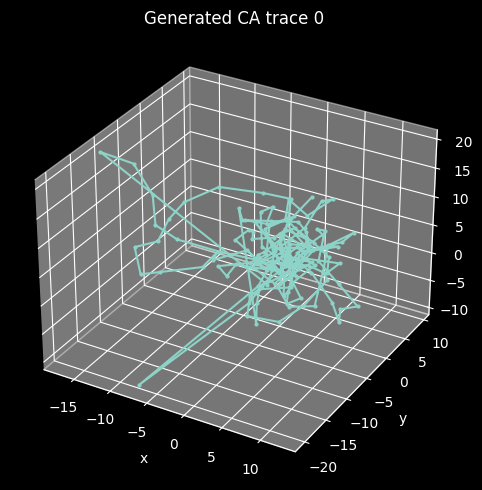

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Generated example 1
{'n_residues': 63.0, 'mean_adjacent_ca': 3.621483325958252, 'fraction_adjacent_ca_in_band': 0.19354838132858276, 'mean_n_ca': 1.3331782817840576, 'mean_ca_c': 1.453891634941101, 'mean_c_o': 1.0893634557724, 'mean_c_n': 1.1915045976638794, 'radius_of_gyration': 7.268030166625977}


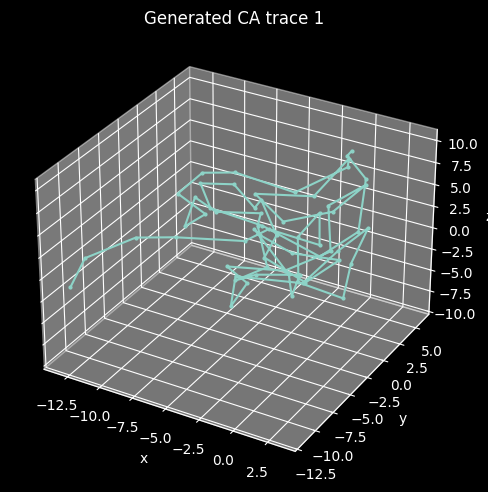

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [12]:
for index in range(min(2, sampled_coords.shape[0])):
    print(f'Generated example {index}')
    print(backbone_structure_summary(sampled_coords[index].cpu(), sample_mask[index].cpu()))
    plot_ca_trace_from_batch(sampled_coords[index].cpu(), sample_mask[index].bool().cpu(), title=f'Generated CA trace {index}')
    render_backbone_example(sampled_coords[index].cpu(), sample_mask[index].cpu(), title=f'Generated backbone {index}')

## 9. V3 diagnostic evaluation


In [13]:
model_parameter_count = sum(parameter.numel() for parameter in model.parameters())
train_chunk_count_summary = train_chunked_df.groupby('parent_chain_id').size()
best_epoch_row = history_df.loc[history_df['validation_loss'].idxmin()].to_dict()

def config_row(key: str, value: object) -> dict[str, object]:
    """Return a Parquet-safe config row with stable column types."""
    is_bool = isinstance(value, bool)
    is_int = isinstance(value, int) and not is_bool
    is_float = isinstance(value, float)
    return {
        'key': key,
        'value_text': str(value),
        'value_int': int(value) if is_int else pd.NA,
        'value_float': float(value) if (is_int or is_float) else np.nan,
    }

run_config_summary = pd.DataFrame([
    config_row('artifact_run_name', ARTIFACT_RUN_NAME),
    config_row('seed', SEED),
    config_row('device', str(device)),
    config_row('device_name', device_name),
    config_row('max_seq_length', MAX_SEQ_LENGTH),
    config_row('backbone_atoms', ','.join(BACKBONE_ATOMS)),
    config_row('train_chains', len(train_df)),
    config_row('validation_chains', len(validation_df)),
    config_row('test_chains', len(test_df)),
    config_row('train_chunks', len(train_chunked_df)),
    config_row('train_chunk_stride', TRAIN_CHUNK_STRIDE),
    config_row('median_chunks_per_train_chain', float(train_chunk_count_summary.median())),
    config_row('max_chunks_per_train_chain', int(train_chunk_count_summary.max())),
    config_row('timesteps', TIMESTEPS),
    config_row('epochs', EPOCHS),
    config_row('batch_size', BATCH_SIZE),
    config_row('optimizer', 'Adam'),
    config_row('learning_rate', optimizer.param_groups[0]['lr']),
    config_row('model_type', MODEL_TYPE),
    config_row('model_hidden_dim', MODEL_HIDDEN_DIM),
    config_row('model_num_layers', MODEL_NUM_LAYERS),
    config_row('model_time_embedding_dim', MODEL_TIME_EMBEDDING_DIM),
    config_row('model_parameter_count', model_parameter_count),
    config_row('best_epoch', int(best_epoch_row['epoch'])),
    config_row('best_validation_loss', float(best_epoch_row['validation_loss'])),
    config_row('best_test_loss_at_reported_epoch', float(best_epoch_row['test_loss'])),
])
run_config_summary['value_int'] = run_config_summary['value_int'].astype('Int64')

display(run_config_summary)
save_table_artifact(run_config_summary, 'v3_run_config_summary')

,key,value_text,value_int,value_float
0,artifact_run_name,v3,<NA>,NaN
1,seed,42,42,4.200000e+01
2,device,cuda,<NA>,NaN
3,device_name,NVIDIA L4,<NA>,NaN
4,max_seq_length,256,256,2.560000e+02
5,backbone_atoms,"N,CA,C,O",<NA>,NaN
6,train_chains,18024,18024,1.802400e+04
7,validation_chains,608,608,6.080000e+02
8,test_chains,1120,1120,1.120000e+03
9,train_chunks,27706,27706,2.770600e+04


{'csv': PosixPath('/content/latent-structure-diffusion/results/v3/tables/v3_run_config_summary.csv'),
 'parquet': PosixPath('/content/latent-structure-diffusion/results/v3/tables/v3_run_config_summary.parquet')}

### Fixed-timestep denoising diagnostics

The training loss samples timesteps uniformly, which is good for optimization but hides where the model is weak. This diagnostic evaluates the same trained model at fixed low, medium, and high noise levels on held-out data.

,split,timestep,noise_fraction,loss,x0_rmse,n_batches
0,validation,1,0.01,0.693898,0.008331,19
1,validation,5,0.05,0.372731,0.030612,19
2,validation,10,0.10,0.285373,0.053694,19
3,validation,25,0.25,0.158048,0.101297,19
4,validation,50,0.50,0.094745,0.164810,19
5,validation,75,0.75,0.074554,0.238813,19
6,validation,100,1.00,0.066191,0.340388,19
7,test,1,0.01,0.695790,0.008342,35
8,test,5,0.05,0.373773,0.030654,35
9,test,10,0.10,0.285350,0.053692,35


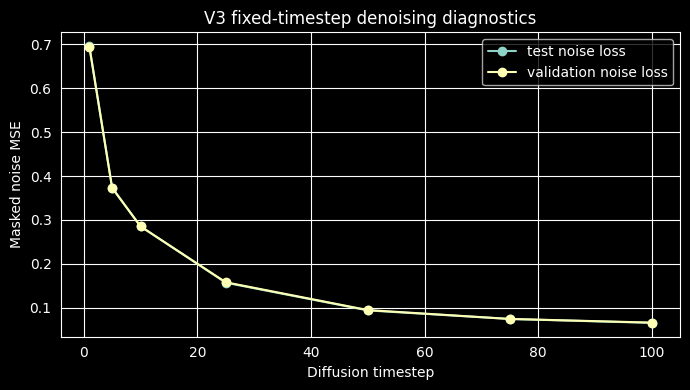

In [14]:
@torch.no_grad()
def evaluate_fixed_timesteps(
    model: torch.nn.Module,
    loader: DataLoader,
    split_name: str,
    timesteps_to_check: list[int],
    stats: BackboneNormalizationStats,
    schedule: dict[str, torch.Tensor],
    target_device: torch.device,
    max_batches: int | None = None,
) -> pd.DataFrame:
    model.eval()
    rows = []
    for timestep in timesteps_to_check:
        totals = defaultdict(float)
        n_batches = 0
        for batch_index, batch in enumerate(loader):
            if max_batches is not None and batch_index >= max_batches:
                break
            coords_flat, mask = prepare_batch_for_diffusion(batch, target_device, stats)
            t = torch.full((coords_flat.shape[0],), timestep, device=target_device, dtype=torch.long)
            noise = torch.randn_like(coords_flat)
            x_t = q_sample(coords_flat, t, noise, schedule['alpha_bars'])
            pred_noise = model(x_t, t, mask)
            loss = masked_noise_mse(pred_noise, noise, mask)
            x0_pred = predict_x0(x_t, t, pred_noise, schedule['alpha_bars'])
            recon_rmse = masked_coordinate_rmse(x0_pred, coords_flat, mask)
            totals['loss'] += float(loss.detach().cpu())
            totals['x0_rmse'] += float(recon_rmse.detach().cpu())
            n_batches += 1
        rows.append({
            'split': split_name,
            'timestep': timestep,
            'noise_fraction': timestep / TIMESTEPS,
            'loss': totals['loss'] / max(n_batches, 1),
            'x0_rmse': totals['x0_rmse'] / max(n_batches, 1),
            'n_batches': n_batches,
        })
    return pd.DataFrame(rows)

TIMESTEP_DIAGNOSTIC_POINTS = [1, 5, 10, 25, 50, 75, 100]
validation_timestep_df = evaluate_fixed_timesteps(
    model,
    validation_loader,
    'validation',
    TIMESTEP_DIAGNOSTIC_POINTS,
    normalization_stats,
    noise_schedule,
    device,
)
test_timestep_df = evaluate_fixed_timesteps(
    model,
    test_loader,
    'test',
    TIMESTEP_DIAGNOSTIC_POINTS,
    normalization_stats,
    noise_schedule,
    device,
)
timestep_diagnostics_df = pd.concat([validation_timestep_df, test_timestep_df], ignore_index=True)

display(timestep_diagnostics_df)
save_table_artifact(timestep_diagnostics_df, 'v3_timestep_diagnostics')

fig, ax = plt.subplots(figsize=(7, 4))
for split_name, split_df in timestep_diagnostics_df.groupby('split'):
    ax.plot(split_df['timestep'], split_df['loss'], marker='o', label=f'{split_name} noise loss')
ax.set_xlabel('Diffusion timestep')
ax.set_ylabel('Masked noise MSE')
ax.set_title('V3 fixed-timestep denoising diagnostics')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'v3_timestep_diagnostics.png', dpi=150)
plt.show()

### Broader sample-quality diagnostics

V3 keeps the broader validation-shaped sample set from V2 and compares generated and real structural metric distributions. When `results/v2/` is available under the same artifact base directory, this section also writes a direct V3-versus-V2 metric comparison.


In [15]:
@torch.no_grad()
def collect_conditioning_masks(loader: DataLoader, target_count: int) -> tuple[torch.Tensor, torch.Tensor]:
    coords_batches = []
    mask_batches = []
    seen = 0
    for batch in loader:
        coords = batch['coords']
        mask = batch['mask']
        remaining = target_count - seen
        coords_batches.append(coords[:remaining])
        mask_batches.append(mask[:remaining])
        seen += min(coords.shape[0], remaining)
        if seen >= target_count:
            break
    return torch.cat(coords_batches, dim=0), torch.cat(mask_batches, dim=0)

@torch.no_grad()
def sample_and_evaluate_masks(
    model: torch.nn.Module,
    masks: torch.Tensor,
    real_coords: torch.Tensor,
    stats: BackboneNormalizationStats,
    schedule: dict[str, torch.Tensor],
    target_device: torch.device,
    sample_batch_size: int = 8,
) -> tuple[pd.DataFrame, pd.DataFrame, torch.Tensor]:
    model.eval()
    generated_coord_batches = []
    real_rows = []
    generated_rows = []
    for start in range(0, masks.shape[0], sample_batch_size):
        end = min(start + sample_batch_size, masks.shape[0])
        batch_mask = masks[start:end].to(target_device)
        sampled_flat = sample_backbone(
            model,
            schedule,
            shape=(batch_mask.shape[0], MAX_SEQ_LENGTH, 12),
            mask=batch_mask,
            device=target_device,
        )
        sampled_coords_norm = unflatten_backbone(sampled_flat)
        generated_coords = invert_coordinate_normalisation(sampled_coords_norm, stats).cpu()
        generated_coord_batches.append(generated_coords)
        for local_index in range(generated_coords.shape[0]):
            index = start + local_index
            real_rows.append({
                'kind': 'real',
                'index': index,
                **backbone_structure_summary(real_coords[index], masks[index]),
            })
            generated_rows.append({
                'kind': 'generated',
                'index': index,
                **backbone_structure_summary(generated_coords[local_index], masks[index]),
            })
    return pd.DataFrame(real_rows), pd.DataFrame(generated_rows), torch.cat(generated_coord_batches, dim=0)


def build_metric_summary(comparison_df: pd.DataFrame) -> pd.DataFrame:
    return comparison_df.groupby('kind', as_index=False).agg(
        n_structures=('index', 'count'),
        mean_n_residues=('n_residues', 'mean'),
        mean_adjacent_ca=('mean_adjacent_ca', 'mean'),
        std_adjacent_ca=('mean_adjacent_ca', 'std'),
        mean_fraction_adjacent_ca_in_band=('fraction_adjacent_ca_in_band', 'mean'),
        mean_n_ca=('mean_n_ca', 'mean'),
        mean_ca_c=('mean_ca_c', 'mean'),
        mean_c_o=('mean_c_o', 'mean'),
        mean_c_n=('mean_c_n', 'mean'),
        mean_radius_of_gyration=('radius_of_gyration', 'mean'),
        std_radius_of_gyration=('radius_of_gyration', 'std'),
    )


def build_structural_gap_summary(metric_summary: pd.DataFrame) -> pd.DataFrame:
    real_means = metric_summary[metric_summary['kind'] == 'real'].iloc[0]
    generated_means = metric_summary[metric_summary['kind'] == 'generated'].iloc[0]
    return pd.DataFrame([
        {
            'metric': 'mean_adjacent_ca',
            'real_mean': real_means['mean_adjacent_ca'],
            'generated_mean': generated_means['mean_adjacent_ca'],
            'generated_minus_real': generated_means['mean_adjacent_ca'] - real_means['mean_adjacent_ca'],
            'interpretation': 'Generated adjacent CA spacing should be close to the real mean around 3.8 A.',
        },
        {
            'metric': 'fraction_adjacent_ca_in_band',
            'real_mean': real_means['mean_fraction_adjacent_ca_in_band'],
            'generated_mean': generated_means['mean_fraction_adjacent_ca_in_band'],
            'generated_minus_real': generated_means['mean_fraction_adjacent_ca_in_band'] - real_means['mean_fraction_adjacent_ca_in_band'],
            'interpretation': 'Low generated fraction indicates broken local CA geometry.',
        },
        {
            'metric': 'radius_of_gyration',
            'real_mean': real_means['mean_radius_of_gyration'],
            'generated_mean': generated_means['mean_radius_of_gyration'],
            'generated_minus_real': generated_means['mean_radius_of_gyration'] - real_means['mean_radius_of_gyration'],
            'interpretation': 'Low generated radius indicates global collapse or over-compact sampling.',
        },
    ])


def load_v2_reference_metric_summary() -> pd.DataFrame | None:
    reference_path = ARTIFACT_BASE_DIR / 'v2' / 'tables' / 'v2_real_vs_generated_metric_summary.csv'
    if not reference_path.exists():
        print(f'V2 reference metric summary not found at {reference_path}; skipping direct V2 comparison.')
        return None
    return pd.read_csv(reference_path)


def load_v2_reference_collapse_summary() -> pd.DataFrame | None:
    reference_path = ARTIFACT_BASE_DIR / 'v2' / 'tables' / 'v2_collapse_summary.csv'
    if not reference_path.exists():
        print(f'V2 reference collapse summary not found at {reference_path}; skipping collapse comparison.')
        return None
    return pd.read_csv(reference_path)


V3_SAMPLE_COUNT = min(32, len(validation_dataset))
v3_real_coords, v3_sample_masks = collect_conditioning_masks(validation_loader, V3_SAMPLE_COUNT)
v3_real_eval_df, v3_generated_eval_df, v3_sampled_coords = sample_and_evaluate_masks(
    model,
    v3_sample_masks,
    v3_real_coords,
    normalization_stats,
    noise_schedule,
    device,
    sample_batch_size=8,
)

v3_comparison_df = pd.concat([v3_real_eval_df, v3_generated_eval_df], ignore_index=True)
v3_metric_summary = build_metric_summary(v3_comparison_df)
v3_gap_summary = build_structural_gap_summary(v3_metric_summary)

real_rg_median = float(v3_real_eval_df['radius_of_gyration'].median())
collapse_radius_threshold = 0.5 * real_rg_median
v3_generated_eval_df['collapse_flag'] = v3_generated_eval_df['radius_of_gyration'] < collapse_radius_threshold
v3_generated_eval_df['poor_ca_band_flag'] = v3_generated_eval_df['fraction_adjacent_ca_in_band'] < 0.8
collapse_summary = pd.DataFrame([
    {
        'sample_count': len(v3_generated_eval_df),
        'real_radius_median': real_rg_median,
        'collapse_radius_threshold': collapse_radius_threshold,
        'collapse_fraction': float(v3_generated_eval_df['collapse_flag'].mean()),
        'poor_ca_band_fraction': float(v3_generated_eval_df['poor_ca_band_flag'].mean()),
    }
])

for frame in [v3_metric_summary, v3_gap_summary, collapse_summary]:
    display(frame)

save_table_artifact(v3_real_eval_df, 'v3_real_eval_metrics')
save_table_artifact(v3_generated_eval_df, 'v3_generated_eval_metrics')
save_table_artifact(v3_comparison_df, 'v3_real_vs_generated_summary')
save_table_artifact(v3_metric_summary, 'v3_real_vs_generated_metric_summary')
save_table_artifact(v3_gap_summary, 'v3_structural_gap_summary')
save_table_artifact(collapse_summary, 'v3_collapse_summary')

v2_metric_summary = load_v2_reference_metric_summary()
if v2_metric_summary is not None:
    v2_generated = v2_metric_summary[v2_metric_summary['kind'] == 'generated'].iloc[0]
    v3_generated = v3_metric_summary[v3_metric_summary['kind'] == 'generated'].iloc[0]
    v3_real = v3_metric_summary[v3_metric_summary['kind'] == 'real'].iloc[0]
    v3_vs_v2_metric_comparison = pd.DataFrame([
        {
            'metric': 'mean_adjacent_ca',
            'real_mean': v3_real['mean_adjacent_ca'],
            'v2_generated_mean': v2_generated['mean_adjacent_ca'],
            'v3_generated_mean': v3_generated['mean_adjacent_ca'],
            'v3_minus_v2': v3_generated['mean_adjacent_ca'] - v2_generated['mean_adjacent_ca'],
            'target_direction': 'increase toward 3.8 A',
        },
        {
            'metric': 'fraction_adjacent_ca_in_band',
            'real_mean': v3_real['mean_fraction_adjacent_ca_in_band'],
            'v2_generated_mean': v2_generated['mean_fraction_adjacent_ca_in_band'],
            'v3_generated_mean': v3_generated['mean_fraction_adjacent_ca_in_band'],
            'v3_minus_v2': v3_generated['mean_fraction_adjacent_ca_in_band'] - v2_generated['mean_fraction_adjacent_ca_in_band'],
            'target_direction': 'increase',
        },
        {
            'metric': 'mean_radius_of_gyration',
            'real_mean': v3_real['mean_radius_of_gyration'],
            'v2_generated_mean': v2_generated['mean_radius_of_gyration'],
            'v3_generated_mean': v3_generated['mean_radius_of_gyration'],
            'v3_minus_v2': v3_generated['mean_radius_of_gyration'] - v2_generated['mean_radius_of_gyration'],
            'target_direction': 'increase toward real',
        },
        {
            'metric': 'mean_n_ca',
            'real_mean': v3_real['mean_n_ca'],
            'v2_generated_mean': v2_generated['mean_n_ca'],
            'v3_generated_mean': v3_generated['mean_n_ca'],
            'v3_minus_v2': v3_generated['mean_n_ca'] - v2_generated['mean_n_ca'],
            'target_direction': 'move toward real',
        },
        {
            'metric': 'mean_ca_c',
            'real_mean': v3_real['mean_ca_c'],
            'v2_generated_mean': v2_generated['mean_ca_c'],
            'v3_generated_mean': v3_generated['mean_ca_c'],
            'v3_minus_v2': v3_generated['mean_ca_c'] - v2_generated['mean_ca_c'],
            'target_direction': 'move toward real',
        },
        {
            'metric': 'mean_c_o',
            'real_mean': v3_real['mean_c_o'],
            'v2_generated_mean': v2_generated['mean_c_o'],
            'v3_generated_mean': v3_generated['mean_c_o'],
            'v3_minus_v2': v3_generated['mean_c_o'] - v2_generated['mean_c_o'],
            'target_direction': 'move toward real',
        },
        {
            'metric': 'mean_c_n',
            'real_mean': v3_real['mean_c_n'],
            'v2_generated_mean': v2_generated['mean_c_n'],
            'v3_generated_mean': v3_generated['mean_c_n'],
            'v3_minus_v2': v3_generated['mean_c_n'] - v2_generated['mean_c_n'],
            'target_direction': 'move toward real',
        },
    ])
    display(v3_vs_v2_metric_comparison)
    save_table_artifact(v3_vs_v2_metric_comparison, 'v3_vs_v2_metric_comparison')


v2_collapse_summary = load_v2_reference_collapse_summary()
if v2_collapse_summary is not None:
    v3_vs_v2_collapse_comparison = pd.DataFrame([
        {
            'metric': 'collapse_fraction',
            'v2_value': float(v2_collapse_summary['collapse_fraction'].iloc[0]),
            'v3_value': float(collapse_summary['collapse_fraction'].iloc[0]),
            'v3_minus_v2': float(collapse_summary['collapse_fraction'].iloc[0] - v2_collapse_summary['collapse_fraction'].iloc[0]),
            'target_direction': 'decrease',
        },
        {
            'metric': 'poor_ca_band_fraction',
            'v2_value': float(v2_collapse_summary['poor_ca_band_fraction'].iloc[0]),
            'v3_value': float(collapse_summary['poor_ca_band_fraction'].iloc[0]),
            'v3_minus_v2': float(collapse_summary['poor_ca_band_fraction'].iloc[0] - v2_collapse_summary['poor_ca_band_fraction'].iloc[0]),
            'target_direction': 'decrease',
        },
    ])
    display(v3_vs_v2_collapse_comparison)
    save_table_artifact(v3_vs_v2_collapse_comparison, 'v3_vs_v2_collapse_comparison')


,kind,n_structures,mean_n_residues,mean_adjacent_ca,std_adjacent_ca,mean_fraction_adjacent_ca_in_band,mean_n_ca,mean_ca_c,mean_c_o,mean_c_n,mean_radius_of_gyration,std_radius_of_gyration
0,generated,32,158.15625,3.576828,0.169020,0.257455,1.353867,1.389934,1.112718,1.254872,7.965955,0.553935
1,real,32,158.15625,3.810443,0.023812,0.998626,1.464060,1.525027,1.229193,1.329809,16.213457,2.443865


,metric,real_mean,generated_mean,generated_minus_real,interpretation
0,mean_adjacent_ca,3.810443,3.576828,-0.233615,Generated adjacent CA spacing should be close ...
1,fraction_adjacent_ca_in_band,0.998626,0.257455,-0.741170,Low generated fraction indicates broken local ...
2,radius_of_gyration,16.213457,7.965955,-8.247502,Low generated radius indicates global collapse...


,sample_count,real_radius_median,collapse_radius_threshold,collapse_fraction,poor_ca_band_fraction
0,32,16.340818,8.170409,0.6875,1.0


V2 reference metric summary not found at /content/latent-structure-diffusion/results/v2/tables/v2_real_vs_generated_metric_summary.csv; skipping direct V2 comparison.
V2 reference collapse summary not found at /content/latent-structure-diffusion/results/v2/tables/v2_collapse_summary.csv; skipping collapse comparison.


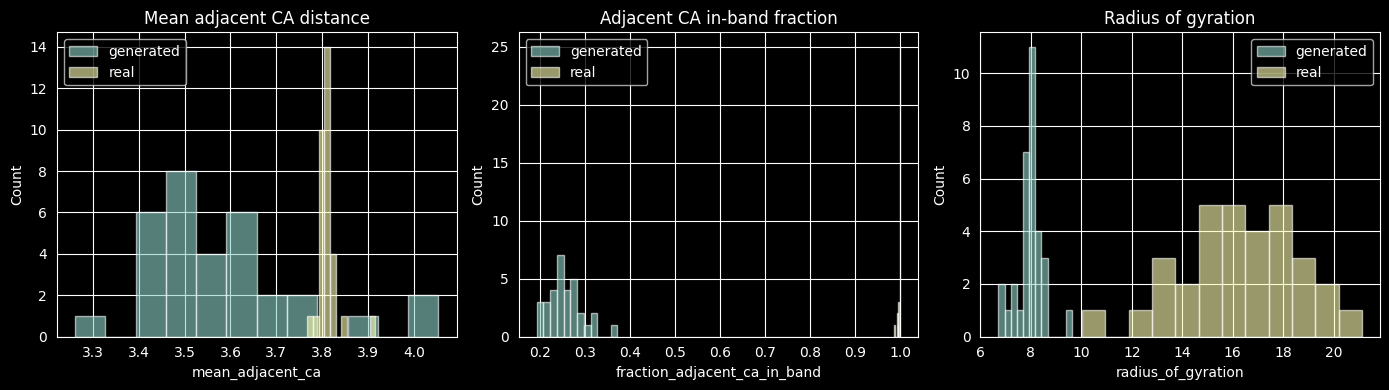

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_to_plot = [
    ('mean_adjacent_ca', 'Mean adjacent CA distance'),
    ('fraction_adjacent_ca_in_band', 'Adjacent CA in-band fraction'),
    ('radius_of_gyration', 'Radius of gyration'),
]
for ax, (metric, label) in zip(axes, metrics_to_plot):
    for kind, frame in v3_comparison_df.groupby('kind'):
        ax.hist(frame[metric].dropna(), bins=12, alpha=0.6, label=kind)
    ax.set_title(label)
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'v3_structural_metric_distributions.png', dpi=150)
plt.show()


## 10. V3 outcome summary

V3 is an architecture upgrade over V2 while keeping the same DDPM pipeline and diagnostic harness. The model no longer treats each residue as a flat 12-value vector. Instead, each `N`, `CA`, `C`, and `O` atom becomes a node conditioned by atom identity, residue position, timestep, and mask state.

The fixed local graph passes messages over backbone-like edges:

- intra-residue `N-CA`, `CA-C`, and `C-O`
- inter-residue peptide `C-N`
- adjacent `CA-CA` trace links

The intended interpretation is direct:

- if radius of gyration rises relative to V2, the atom-graph denoiser reduced global collapse
- if adjacent CA distance and CA in-band fraction improve, local trace geometry improved
- if bond-length means move toward real values, the atom-level representation helped model backbone chemistry
- if generated samples still collapse, the next credible step is stronger geometric losses or an equivariant V4 model rather than more diagnostics alone

The notebook saves V3 history, checkpoint, generated metrics, fixed-timestep diagnostics, structural summaries, collapse flags, plus direct `v3_vs_v2_metric_comparison` and `v3_vs_v2_collapse_comparison` tables when V2 reference metrics are available under the same artifact base directory.
